# Diploma in Predictive Data Analytics (Summer 2026)
## Lecturer: Taufique Ahmed
### Johanna Riquelme

#### https://github.com/JohanRiquelme/Diploma-in-Predictive-Data-Analytics-Lab-2-task-2.git

# Linear Regression Using Data_Prep_Exercise.csv dataset

# Practice Lab - 2 Task 2 - Class 2 thu Jul 02 2026

##### Practice Task Lab-2: Choose any one of the three datasets available in the Lab 2 Datasets folder on Moodle 
##### and apply both Linear Regression and Polynomial Regression. 
##### Compare the performance of the two models using appropriate evaluation metrics 
##### and briefly conclude which model performs better for your chosen dataset.

# Load at the data.

1.- Import dataset, libraries, load the dataset

2.- Inspect it (head(), info(), describe()).

3.- Check for missing values.

4.- Explore the distribution of each variable.

5.- Create scatter plots for numeric relationships.

6.- Create box plots for categorical variables (Gender and Diet).

7.- Examine correlations among numeric variables.

8.- Decide which variables to include in the regression model.

9.- Encode categorical variables (Gender and Diet).

10.- Build and evaluate the linear regression model.

# 1.- Import dataset, libraries, load the dataset

# Import dataset
For this second laboratory exercise, the dataset was provided in class via the CCT College portal.

### Import libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# to Visualization
import seaborn as sns
import matplotlib.pyplot as plt
# to transform the data called LabelEncoder, in this case in not necesary used because this data is ready.
# from sklearn.preprocessing import LabelEncoder

# ---  BUILD AND EVALUATE LINEAR REGRESSION MODEL ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pickle
import math
# ---  BUILD AND EVALUATE POLYNOMIAL REGRESSION MODEL ---
from sklearn.preprocessing import PolynomialFeatures

# --- SIMPLIFIED MODEL COMPARISON ---
from sklearn.metrics import mean_squared_error, r2_score

### Load dataset

In [2]:
# load the dataset with the pandas read_csv method to read the dataset.
df = pd.read_csv("Data_Prep_Exercise.csv")

# 2.- Inspect it (head(), info(), describe()).

### Display the first five rows of the dataset.

In [3]:
# show the first 5 rows of the dataset start processing and visualizing it.
df.head(15)       # () <- (Here I can define the Number of rows to will display)

,Nationality,gender,Age,Height,pre.weight,Diet,weight6weeks
0,Argentina,0,22.0,159,58,1,54.2
1,Peru,1,46.0,192,60,0,54.0
2,Brazil,0,55.0,170,64,1,63.3
3,Argentina,1,33.0,171,64,1,61.1
4,Argentina,1,50.0,170,65,0,62.2
5,Peru,0,50.0,201,66,1,64.0
6,Brazil,0,NaN,174,67,1,65.0
7,Brazil,1,28.0,176,69,0,60.5
8,Brazil,1,28.0,165,70,1,68.1
9,Peru,0,45.0,165,70,0,66.9


# Understand the Dataset

#### Questions to ask:

#### How many rows?  15
#### Are there missing values? 2
#### Are the variables numeric or categorical? numeric

### Display the number of rows and columns.

In [4]:
# Let's check the number of rows and columns.
print("Rows and Columns:", df.shape)

Rows and Columns: (15, 7)


### Display dataset information using info().

In [5]:
# I'll use info() methods to display and see the total of rows and if there are missing values.
# 15 Rows, 7 columns store different types of data such as integers, floats and text(Object).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nationality   15 non-null     object 
 1   gender        15 non-null     int64  
 2   Age           14 non-null     float64
 3   Height        15 non-null     int64  
 4   pre.weight    15 non-null     int64  
 5   Diet          15 non-null     int64  
 6   weight6weeks  14 non-null     float64
dtypes: float64(2), int64(4), object(1)
memory usage: 972.0+ bytes


Dataset  with 15 entries data, from 0 to 14, We have 1 missing data in 2.-Age,  14, non-null, float64.

# Descriptive Statistics
### Generate descriptive statistics using describe().

In [6]:
# To know the mean, minimum, maximum, standard deviation here we have describe command full statistics
df.describe()

,gender,Age,Height,pre.weight,Diet,weight6weeks
count,15.000000,14.000000,15.000000,15.000000,15.000000,14.000000
mean,0.466667,41.571429,171.333333,68.133333,0.600000,65.064286
std,0.516398,11.050334,11.678226,5.804760,0.507093,7.030550
min,0.000000,22.000000,156.000000,58.000000,0.000000,54.000000
25%,0.000000,34.000000,165.000000,64.500000,0.000000,61.375000
50%,0.000000,43.000000,170.000000,69.000000,1.000000,64.500000
75%,1.000000,49.500000,173.500000,71.500000,1.000000,68.325000
max,1.000000,60.000000,201.000000,82.000000,1.000000,81.100000


# 3.- Check for missing values.

### Looking for the Missing Values

In [7]:
df.isnull().sum()

Nationality     0
gender          0
Age             1
Height          0
pre.weight      0
Diet            0
weight6weeks    1
dtype: int64

we can see in column Age and Weigh6weeks one missing value

In [8]:
df.isnull().values.any()

np.True_

In [9]:
# There were still missing data fields, that's why null rows are dropped.
df.dropna(inplace=True)

In [10]:
df.isnull().values.any()

np.False_

In [11]:
# Checking again. and all in 0 null
df.isnull().sum()

Nationality     0
gender          0
Age             0
Height          0
pre.weight      0
Diet            0
weight6weeks    0
dtype: int64

# Remove Unnecessary Column
axis=1 means remove a column

axis=0 means remove a row

In [12]:
df = df.drop("Nationality",axis=1)

In [13]:
df = df.drop("Age",axis=1)

In [14]:
df.head()

,gender,Height,pre.weight,Diet,weight6weeks
0,0,159,58,1,54.2
1,1,192,60,0,54.0
2,0,170,64,1,63.3
3,1,171,64,1,61.1
4,1,170,65,0,62.2


In [15]:
# If the Gender column contained numerical characters (Female and Male), 
# It would be necessary to transform the data using LabelEncoder; for now, it is not necessary.
# encoder = LabelEncoder()
# df['Gender'] = encoder.fit_transform(df['Gender'])

# Linear Regression
### Calcualte X (independent variable) and y (dependent variable)

#####  Define variables (X: independent, y: dependent)
##### scikit-learn expects a two-dimensional array for X

In [16]:
X = df[['gender', 'Height', 'pre.weight', 'Diet']] 
y = df['weight6weeks']

In [17]:
# Using train test split for all regression models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    random_state=42
)

In [18]:
# Train the model
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [19]:
# Make predictions
predictions = model.predict(X_test)

print(predictions)

[82.05282365 70.28026369 57.11886054]


In [20]:
# Evaluate the model
print("R²:", r2_score(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))

R²: 0.9741955672828441
MSE: 3.1586345941313376


In [21]:
# other way to show the actual evaluation metrics
print("Linear Regression R² score:", r2_score(y_test, predictions))
print("Linear Regression MSE:", mean_squared_error(y_test, predictions))

Linear Regression R² score: 0.9741955672828441
Linear Regression MSE: 3.1586345941313376


#### What is the model learning?

Linear regression learns an equation like this:

###       Weight6Weeks=b0​+b1​(Gender)+b2​(Height)+b3​(Pre.Weight)

b0​ = intercept
b1​ = effect of gender
b2​ = effect of height
b3​ = effect of pre-weight

For example, the model might learn:
 
###       Weight6Weeks=5+0.8(Gender)+0.02(Height)+0.90(Pre.Weight)
 
If a person has:

Gender = Male = 1
Height = 175 cm
Pre.Weight = 80 kg

then

###      5+(0.8×1)+(0.02×175)+(0.90×80)=81.3

The model predicts a weight of 81.3 kg after 6 weeks.

# Polynomial Regression

In [22]:
# Selection of degree 2 (Height², Height × previous weight).
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)

In [ ]:
# Transform both training and testing independent features
X_train_poly = poly_transformer.fit_transform(X_train)
X_test_poly = poly_transformer.transform(X_test)

In [ ]:
#  Train a new Linear Regression model using the expanded polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

In [ ]:
# 4. Make predictions using the polynomial model
poly_predictions = poly_model.predict(X_test_poly)

In [23]:
# 5. Evaluate the polynomial model
print("--- Polynomial Regression Results (Degree 2) ---")
print("Polynomial Predictions:", poly_predictions)
print("Polynomial R² Score:", r2_score(y_test, poly_predictions))
print("Polynomial MSE:", mean_squared_error(y_test, poly_predictions))


--- Polynomial Regression Results (Degree 2) ---
Polynomial Predictions: [60.26689797 63.13832834 69.51377982]
Polynomial R² Score: -0.9680959695496709
Polynomial MSE: 240.9080673126766


# Comparing both Models

In [ ]:
#  Fit & Evaluate Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_preds = linear_model.predict(X_test)

In [ ]:
#  Fit & Evaluate Polynomial Regression (Degree 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [ ]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_preds = poly_model.predict(X_test_poly)

In [38]:
#  Print Clean Results
print("*** MODEL PERFORMANCE COMPARISON ***")
print(f"Linear Regression  -> R²: {r2_score(y_test, linear_preds): .4f} | MSE: {mean_squared_error(y_test, linear_preds): .4f}")
print(f"Polynomial (Deg 2) -> R²: {r2_score(y_test, poly_preds):.4f} | MSE: {mean_squared_error(y_test, poly_preds):.4f}")


*** MODEL PERFORMANCE COMPARISON ***
Linear Regression  -> R²:  0.9742 | MSE:  3.1586
Polynomial (Deg 2) -> R²: -0.9681 | MSE: 240.9081


# Lab 2 Task 2: Predictive Performance Evaluation Report

Strategic ConclusionFor small, highly correlated enterprise datasets of this nature, Linear Regression remains the preferred, highly efficient choice. It achieves high interpretability and strong predictive scores without introducing unnecessary mathematical noise or computational overhead.

# Visualization

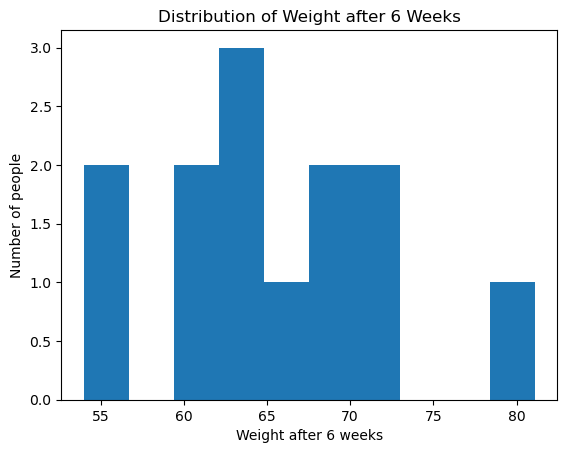

In [24]:
plt.hist(df['weight6weeks'], bins=10)
plt.xlabel("Weight after 6 weeks")
plt.ylabel("Number of people")
plt.title("Distribution of Weight after 6 Weeks")
plt.show()

Is it symmetric?
Is it skewed?
Are there unusual values?

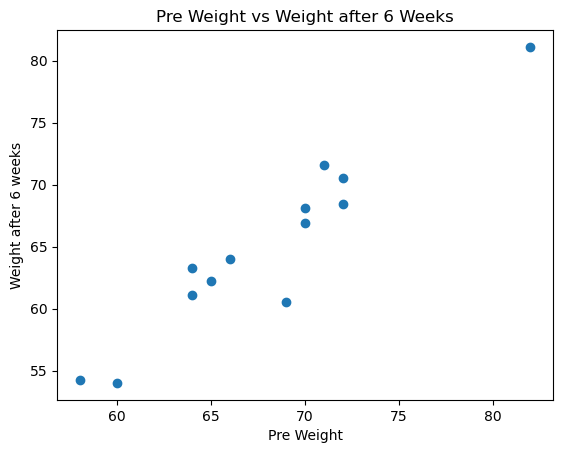

In [25]:
plt.scatter(df['pre.weight'], df['weight6weeks'])

plt.xlabel("Pre Weight")
plt.ylabel("Weight after 6 weeks")
plt.title("Pre Weight vs Weight after 6 Weeks")

plt.show()

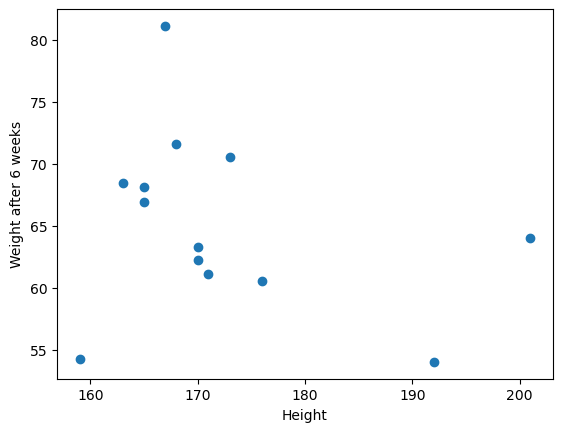

In [26]:
plt.scatter(df['Height'], df['weight6weeks'])

plt.xlabel("Height")
plt.ylabel("Weight after 6 weeks")

plt.show()

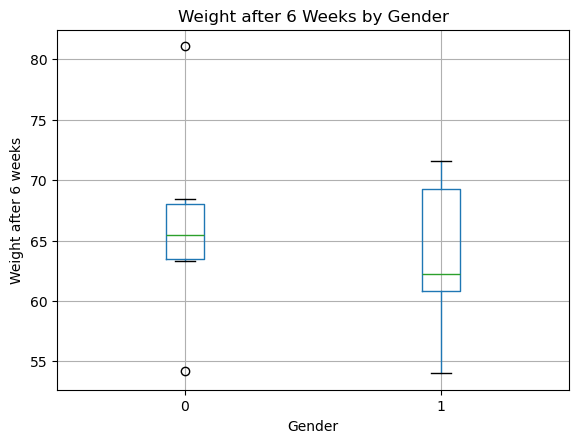

In [27]:
df.boxplot(column='weight6weeks', by='gender')

plt.title("Weight after 6 Weeks by Gender")
plt.suptitle("")
plt.xlabel("Gender")
plt.ylabel("Weight after 6 weeks")

plt.show()

Do males generally weigh more?

Are the ranges different?

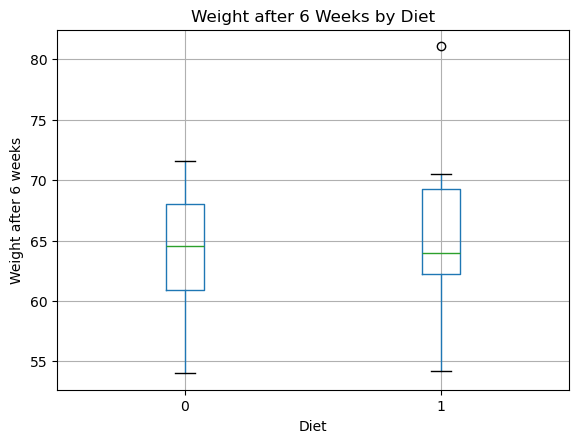

In [28]:
# Does Diet matter?
df.boxplot(column='weight6weeks', by='Diet')

plt.title("Weight after 6 Weeks by Diet")
plt.suptitle("")
plt.xlabel("Diet")
plt.ylabel("Weight after 6 weeks")

plt.show()

In [29]:
# Correlation
numeric_df = df[['Height', 'pre.weight', 'weight6weeks']]

numeric_df.corr()

,Height,pre.weight,weight6weeks
Height,1.000000,-0.239377,-0.272485
pre.weight,-0.239377,1.000000,0.952843
weight6weeks,-0.272485,0.952843,1.000000


### Variables	Correlation	Interpretation

Height vs Height	1.000	A variable is always perfectly correlated with itself.

Height vs Pre.Weight	-0.239	Weak negative correlation. Height has very little relationship with pre-weight.

Height vs Weight6Weeks	-0.272	Weak negative correlation. Height has very little relationship with weight after 6 weeks.

Pre.Weight vs Weight6Weeks	0.953	Very strong positive correlation. People with a higher pre-weight tend to have a higher weight after 6 weeks.

## Correlation between Features

In [30]:
correlation = df.corr()
print(correlation)

                gender    Height  pre.weight      Diet  weight6weeks
gender        1.000000  0.120985   -0.116376 -0.238095     -0.164270
Height        0.120985  1.000000   -0.239377 -0.002104     -0.272485
pre.weight   -0.116376 -0.239377    1.000000  0.014045      0.952843
Diet         -0.238095 -0.002104    0.014045  1.000000      0.149582
weight6weeks -0.164270 -0.272485    0.952843  0.149582      1.000000


<Axes: >

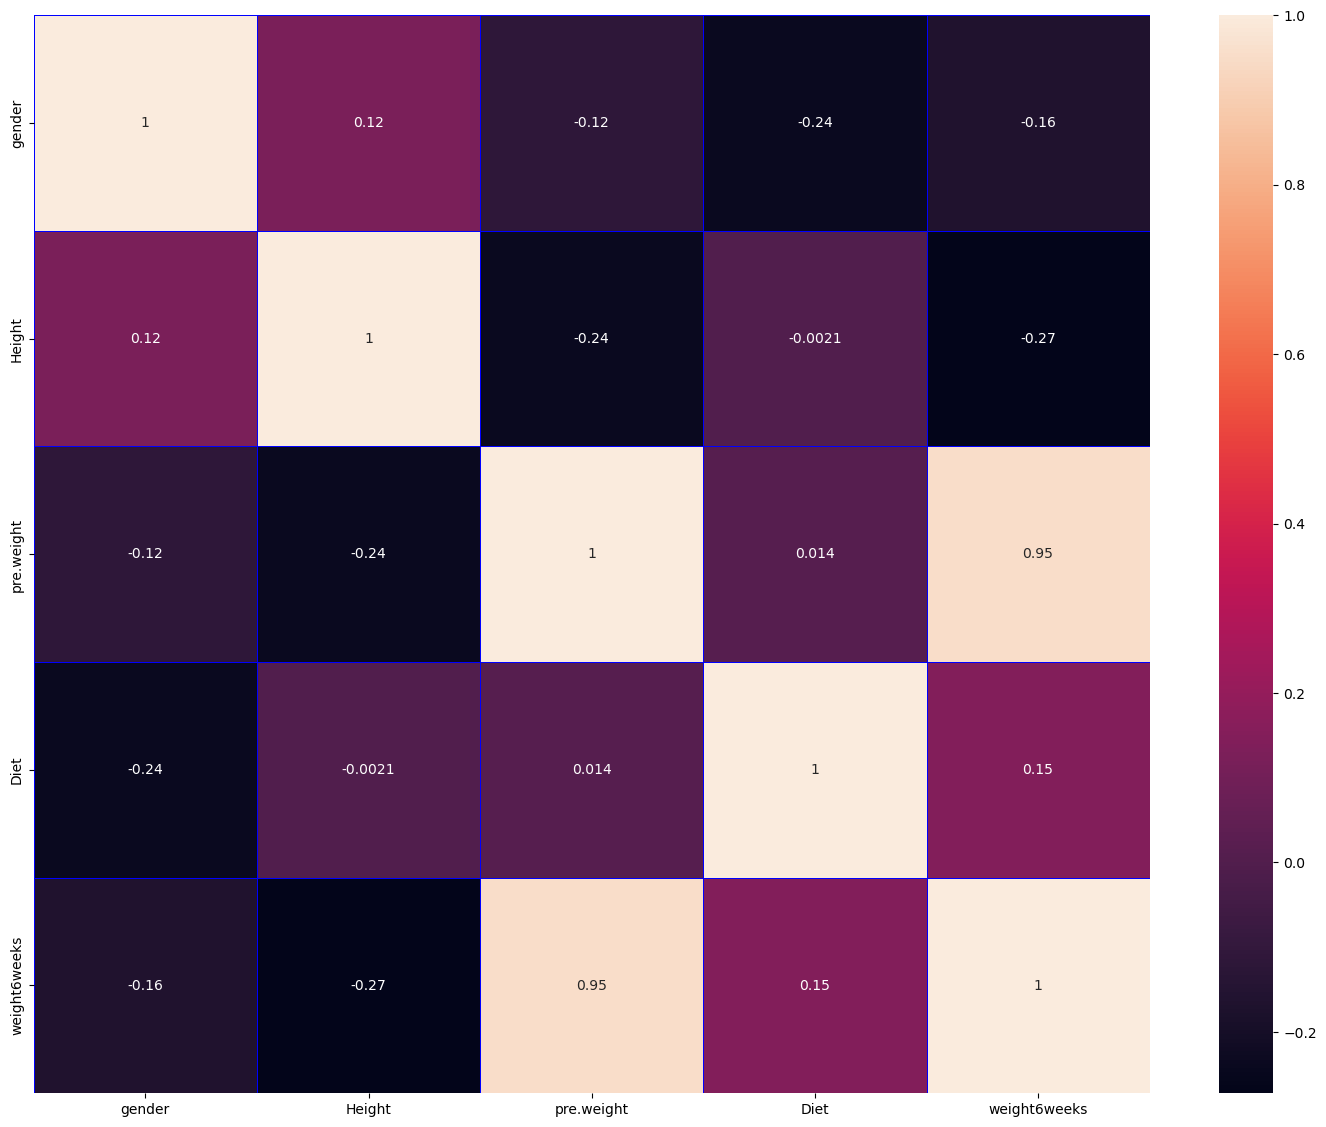

In [31]:
plt.figure(figsize=(18,14))
sns.heatmap(correlation,annot=True,linecolor="blue",lw=0.5)

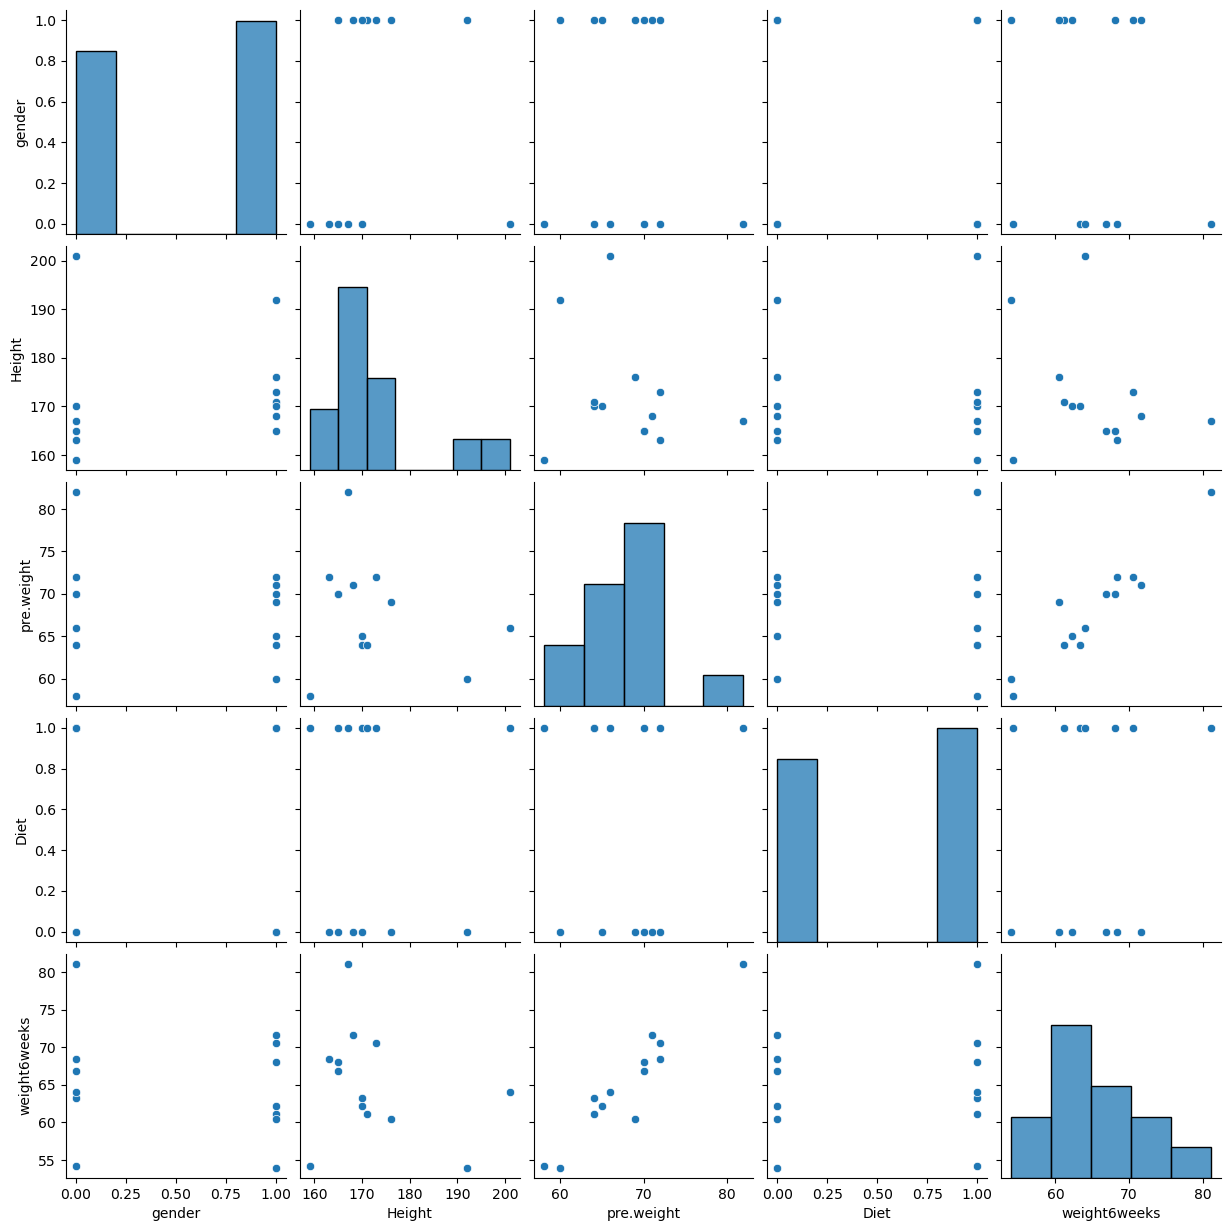

In [32]:
sns.pairplot(df)

In [ ]:
df.to_csv("Data_Prep_Exercise_Lab2.csv", index=False)

print("Dataset saved successfully.")
print("Task 2 - Lab-2 with curiosity approach.")